In [1]:
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")                      # run everything from the project root
sys.path.insert(0, os.getcwd())

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
%matplotlib inline
pd.set_option("display.max_columns", 50)

# 05 · Cluster Analysis
Profile the segments, validate them against actual purchases, and derive actions.

In [2]:
from src import clustering, evaluation
from src.feature_engineering import add_features

model, scaler, info = clustering.load_artifacts()
df = pd.read_csv('data/processed/visitors_cleaned.csv')
feats = add_features(df)
feats['cluster'] = clustering.predict_segments(df, model, scaler)
feats['segment'] = feats.cluster.map(lambda c: info[c]['name'])
profile = evaluation.profile_clusters(feats, feats.cluster)
profile.index = [info[i]['name'] for i in profile.index]
profile.sort_values('conversion_rate', ascending=False).round(3).T

,High-Value Buyers,New Visitor Prospects,Engaged Browsers,Light Browsers,Bouncers
visitors,2118.000,1621.000,5075.000,2743.000,648.000
share,0.174,0.133,0.416,0.225,0.053
avg_pages,61.192,20.725,47.227,7.960,1.795
avg_duration_sec,2412.108,740.677,1830.746,200.789,2.280
avg_time_per_page,43.232,37.203,44.737,31.619,0.511
product_page_share,0.890,0.812,0.903,0.958,0.966
bounce_rate,0.006,0.002,0.009,0.024,0.190
exit_rate,0.020,0.018,0.026,0.065,0.196
page_value,27.981,7.859,0.089,0.058,0.000
new_visitor_share,0.020,0.996,0.000,0.003,0.043


### What defines each segment?

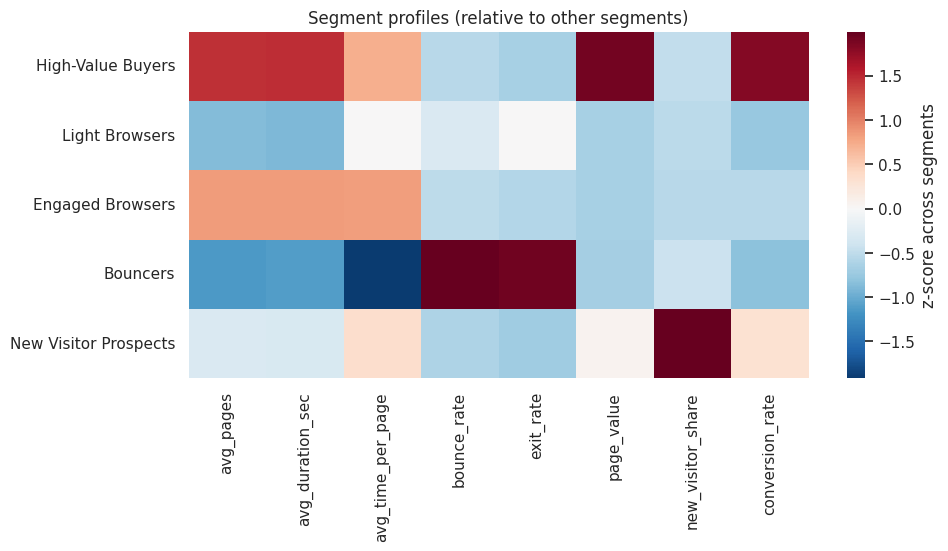

In [3]:
prof = evaluation.profile_clusters(feats, feats.cluster)
evaluation.plot_cluster_heatmap(prof, info); plt.show()

### External validation: purchase rate and revenue share
Purchases were *not* used to build the clusters, so a large spread in purchase rate is evidence the segments are meaningful.

In [4]:
g = feats.groupby('segment').agg(visitors=('Revenue','size'), buyers=('Revenue','sum'))
g['purchase_rate_%'] = (g.buyers / g.visitors * 100).round(1)
g['share_of_all_purchases_%'] = (g.buyers / g.buyers.sum() * 100).round(1)
g = g.sort_values('purchase_rate_%', ascending=False); g

,visitors,buyers,purchase_rate_%,share_of_all_purchases_%
segment,,,,
High-Value Buyers,2118,1156,54.6,60.6
New Visitor Prospects,1621,384,23.7,20.1
Engaged Browsers,5075,315,6.2,16.5
Light Browsers,2743,50,1.8,2.6
Bouncers,648,3,0.5,0.2


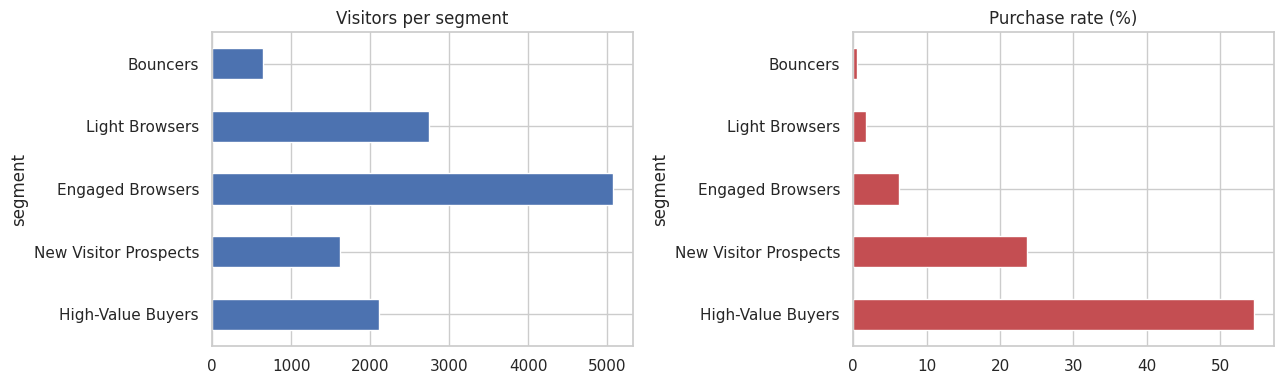

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
g['visitors'].plot.barh(ax=ax[0], color='#4C72B0', title='Visitors per segment')
g['purchase_rate_%'].plot.barh(ax=ax[1], color='#C44E52', title='Purchase rate (%)')
plt.tight_layout(); plt.show()

### Segment mix by month

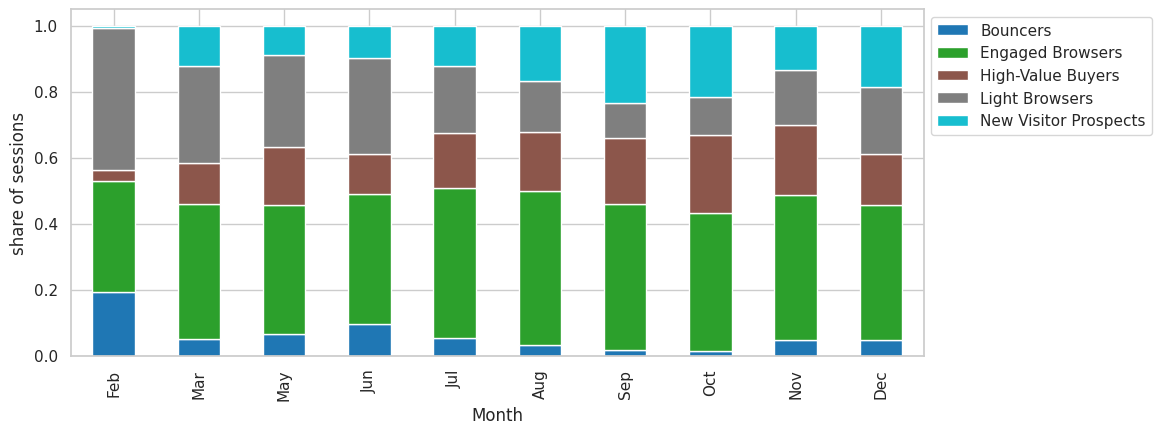

In [6]:
mix = pd.crosstab(feats.Month, feats.segment, normalize='index')
mix = mix.reindex(['Feb','Mar','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
mix.plot.bar(stacked=True, figsize=(11, 4.5), colormap='tab10'); plt.ylabel('share of sessions'); plt.legend(bbox_to_anchor=(1, 1)); plt.show()

### Business recommendations

In [7]:
for cid, v in sorted(info.items(), key=lambda kv: -kv[1]['conversion_rate']):
    print(f"{v['name']}  ({v['share']:.0%} of visitors, {v['conversion_rate']:.1%} purchase rate)")
    print('   who   :', v['description'])
    print('   action:', v['action'], '\n')

High-Value Buyers  (17% of visitors, 54.6% purchase rate)
   who   : Returning visitors who view lots of pages, reach high-value pages and convert at the highest rate.
   action: Protect the experience: loyalty perks, cross-sell/upsell, and a frictionless checkout. 

New Visitor Prospects  (13% of visitors, 23.7% purchase rate)
   who   : First-time visitors with solid engagement and a surprisingly high purchase rate.
   action: Welcome offers, onboarding content and email capture to turn them into returning customers. 

Engaged Browsers  (42% of visitors, 6.2% purchase rate)
   who   : Returning visitors who browse deeply for a long time but rarely reach valuable pages.
   action: Retarget with reminders, comparison tools and limited-time incentives to close the gap. 

Light Browsers  (22% of visitors, 1.8% purchase rate)
   who   : Returning visitors with short, shallow sessions and low purchase intent.
   action: Surface bestsellers and personalised recommendations to deepen the vis